Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

Part 1: Data Preprocessing

In [2]:
# 1. Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
# 2. Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Check for missing values after conversion
print(f"\nMissing values after conversion:\n{df.isnull().sum()}")
# Drop rows with missing values
df = df.dropna()
print(f"\nDataset shape after dropping missing values: {df.shape}")
# 3. Prepare target variable
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"Churn rate: {df['Churn'].mean():.2%}")
# 4. Identify categorical and numerical features
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# 5. One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(df[categorical_cols], drop_first=True)
# Combine with numerical features
X = pd.concat([df[numerical_cols], df_encoded], axis=1)
y = df['Churn']
print(f"\nFeatures after encoding: {X.shape[1]} columns")
print(f"Feature names: {list(X.columns)}")
# 6. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")
# 7. Standardize numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])
print(f"\nPreprocessing completed successfully!")
print(f"Training set ready: {X_train_scaled.shape}")
print(f"Test set ready: {X_test_scaled.shape}")


Dataset shape: (7043, 21)

First few rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Strea

Part 2: Baseline Modeling with Logistic Regression


Logistic Regression Results:
Training Accuracy: 0.8048
Test Accuracy: 0.8045


<Figure size 1000x800 with 0 Axes>

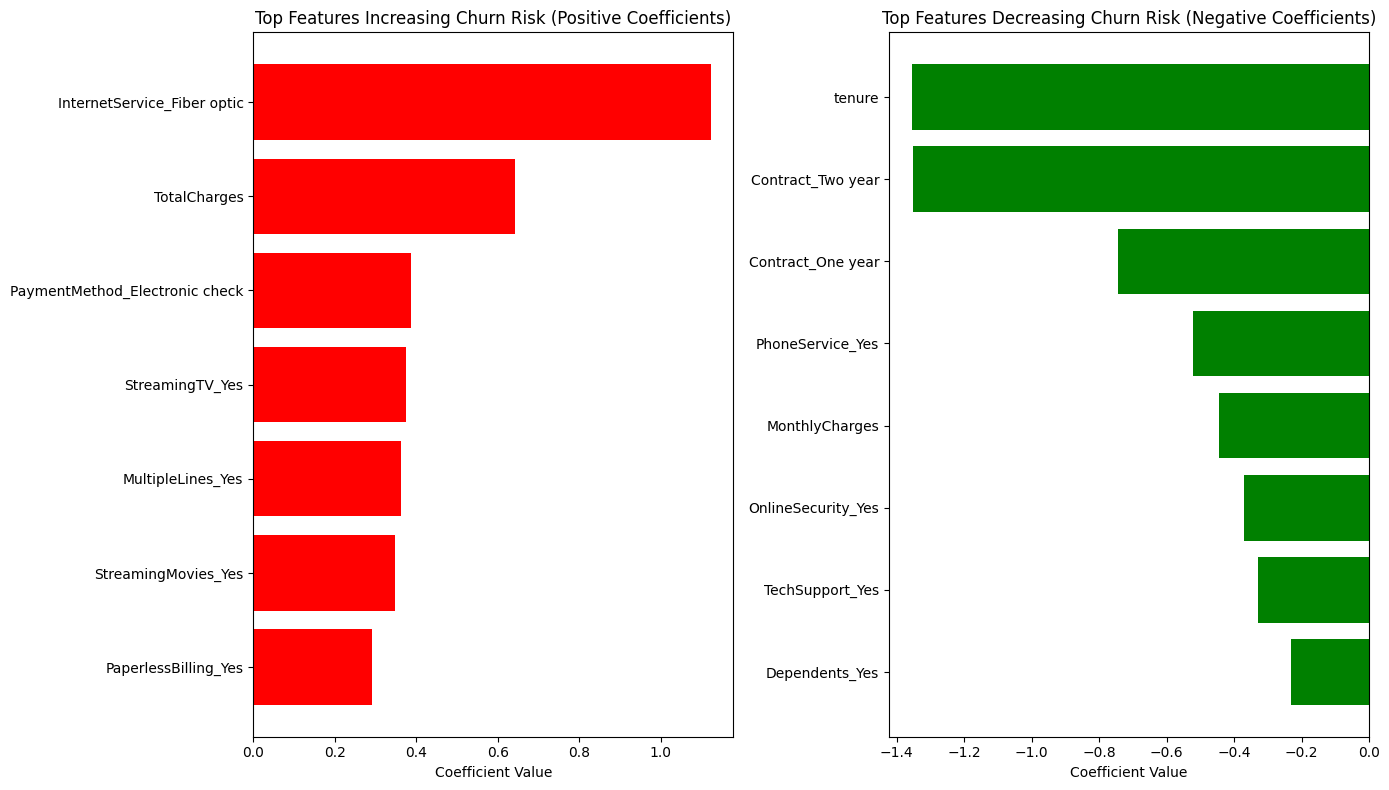


Top 10 features influencing churn:
                       Feature  Coefficient
                        tenure    -1.355817
             Contract_Two year    -1.351225
   InternetService_Fiber optic     1.121685
             Contract_One year    -0.743489
                  TotalCharges     0.641811
              PhoneService_Yes    -0.522947
                MonthlyCharges    -0.445174
PaymentMethod_Electronic check     0.386286
               StreamingTV_Yes     0.374880
            OnlineSecurity_Yes    -0.370820


In [3]:
# Train Logistic Regression model
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)
# Make predictions
y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]
# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0],
    'Abs_Coefficient': np.abs(logreg.coef_[0])
})
# Sort by absolute value for visualization
coefficients_sorted = coefficients.sort_values('Abs_Coefficient', ascending=False)
print(f"\nLogistic Regression Results:")
print(f"Training Accuracy: {logreg.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
# Visualize top coefficients
plt.figure(figsize=(10, 8))
top_n = 15
top_features = coefficients_sorted.head(top_n)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
# Positive coefficients
pos_coeff = top_features[top_features['Coefficient'] > 0].sort_values('Coefficient')
ax1.barh(pos_coeff['Feature'], pos_coeff['Coefficient'], color='red')
ax1.set_xlabel('Coefficient Value')
ax1.set_title('Top Features Increasing Churn Risk (Positive Coefficients)')
# Negative coefficients
neg_coeff = top_features[top_features['Coefficient'] < 0].sort_values('Coefficient', ascending=False)
ax2.barh(neg_coeff['Feature'], neg_coeff['Coefficient'], color='green')
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Top Features Decreasing Churn Risk (Negative Coefficients)')
plt.tight_layout()
plt.show()
print("\nTop 10 features influencing churn:")
print(coefficients_sorted[['Feature', 'Coefficient']].head(10).to_string(index=False))


The Logistic Regression model performed consistently well, achieving a training accuracy of 80.48% and a test accuracy of 80.45%, which indicates excellent generalization with no noticeable overfitting. The model also allowed us to interpret the most important factors influencing customer churn. Features with negative coefficients—such as tenure, one-year and two-year contract types, having phone service, higher monthly charges, and having online security—were associated with a reduced likelihood of churn. Overall, the model provides meaningful insights into the drivers of customer churn and confirms that Logistic Regression is effective for both prediction and interpretability in this dataset.

Part 3: Decision Trees and Overfitting Analysis


DECISION TREE PERFORMANCE COMPARISON
Unconstrained Tree - Training Accuracy: 0.9988, Test Accuracy: 0.7342
Pruned Tree       - Training Accuracy: 0.7927, Test Accuracy: 0.7754

Overfitting Analysis:
Unconstrained gap: 0.2646
Pruned gap:        0.0173
Conclusion: The pruned tree generalizes better (less overfitting).


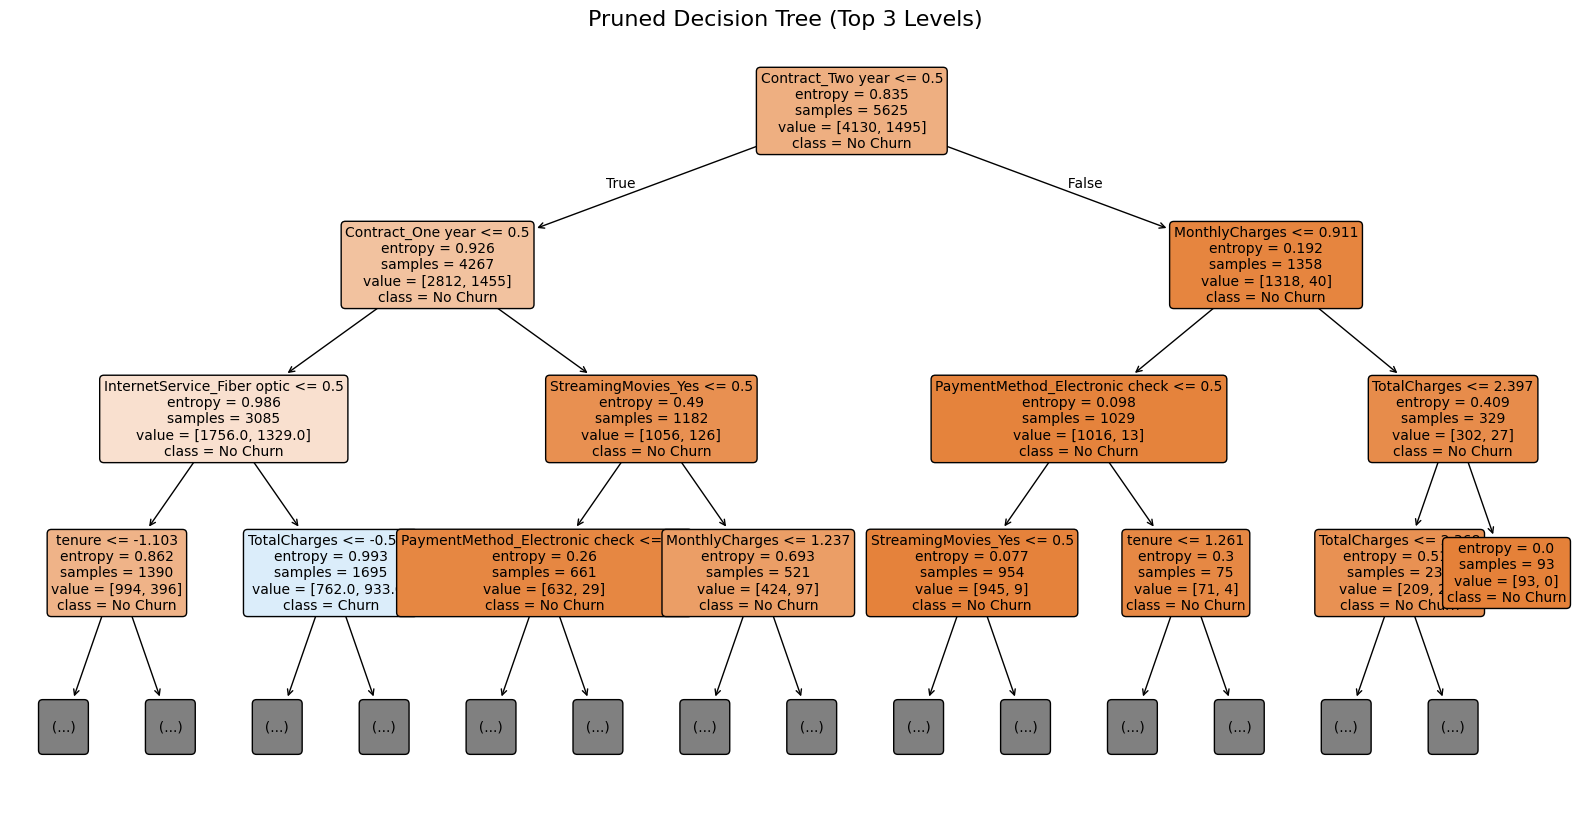


Top 10 most important features (pruned tree):
                       Feature  Importance
             Contract_Two year    0.354283
             Contract_One year    0.238937
   InternetService_Fiber optic    0.117154
                  TotalCharges    0.106902
                        tenure    0.053735
           StreamingMovies_Yes    0.036572
PaymentMethod_Electronic check    0.032425
                MonthlyCharges    0.031320
            InternetService_No    0.019467
                Dependents_Yes    0.004454


In [4]:
# 1. Unconstrained Decision Tree
unconstrained_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
unconstrained_tree.fit(X_train_scaled, y_train)
y_pred_unconstrained_train = unconstrained_tree.predict(X_train_scaled)
y_pred_unconstrained_test = unconstrained_tree.predict(X_test_scaled)
train_acc_unconstrained = accuracy_score(y_train, y_pred_unconstrained_train)
test_acc_unconstrained = accuracy_score(y_test, y_pred_unconstrained_test)
# 2. Pruned Decision Tree
pruned_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
pruned_tree.fit(X_train_scaled, y_train)
y_pred_pruned_train = pruned_tree.predict(X_train_scaled)
y_pred_pruned_test = pruned_tree.predict(X_test_scaled)
train_acc_pruned = accuracy_score(y_train, y_pred_pruned_train)
test_acc_pruned = accuracy_score(y_test, y_pred_pruned_test)
# Print comparison
print("\nDECISION TREE PERFORMANCE COMPARISON")
print(f"Unconstrained Tree - Training Accuracy: {train_acc_unconstrained:.4f}, Test Accuracy: {test_acc_unconstrained:.4f}")
print(f"Pruned Tree       - Training Accuracy: {train_acc_pruned:.4f}, Test Accuracy: {test_acc_pruned:.4f}")
# Overfitting analysis
overfitting_gap_unconstrained = train_acc_unconstrained - test_acc_unconstrained
overfitting_gap_pruned = train_acc_pruned - test_acc_pruned
print("\nOverfitting Analysis:")
print(f"Unconstrained gap: {overfitting_gap_unconstrained:.4f}")
print(f"Pruned gap:        {overfitting_gap_pruned:.4f}")
if overfitting_gap_pruned < overfitting_gap_unconstrained:
    print("Conclusion: The pruned tree generalizes better (less overfitting).")
else:
    print("Conclusion: The unconstrained tree shows less overfitting.")
# Visualize pruned tree
plt.figure(figsize=(20, 10))
plot_tree(
    pruned_tree,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)
plt.title("Pruned Decision Tree (Top 3 Levels)", fontsize=16)
plt.show()
# Print top feature
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': pruned_tree.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop 10 most important features (pruned tree):")
print(feature_importances.head(10).to_string(index=False))


The Decision Tree analysis highlights the difference between an unconstrained model and a pruned, complexity-controlled version. The unconstrained tree achieved an extremely high training accuracy of 99.88% but only 73.42% accuracy on the test set, resulting in a large generalization gap of 0.2646. This clearly indicates severe overfitting.Examining feature importance in the pruned tree contribute to churn prediction, although to a lesser degree. Overall, the pruned decision tree provides a more reliable and interpretable model, successfully avoiding the overfitting seen in the unconstrained version

Part 4: Ensemble Learning (Bagging and Boosting)

In [5]:
# 1. Random Forest (Bagging)
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. XGBoost (Boosting)
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
print("ENSEMBLE MODELS TRAINED")
print("Random Forest (Bagging) - 100 trees")
print("XGBoost (Boosting) - 100 estimators")

ENSEMBLE MODELS TRAINED
Random Forest (Bagging) - 100 trees
XGBoost (Boosting) - 100 estimators


Part 5: Model Evaluation and Comparison


MODEL PERFORMANCE COMPARISON:
                      Accuracy  Precision  Recall  F1-Score     AUC
Model                                                              
Logistic Regression     0.8045     0.6505  0.5722    0.6088  0.8361
Pruned Decision Tree    0.7754     0.5980  0.4733    0.5284  0.8159
Random Forest           0.7839     0.6190  0.4866    0.5449  0.8164
XGBoost                 0.7910     0.6242  0.5374    0.5776  0.8301

Model with highest Recall: Logistic Regression (Recall = 0.5722)


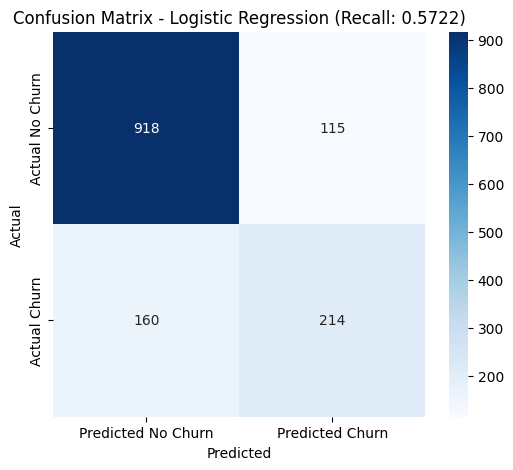


Confusion Matrix Analysis for Logistic Regression:
True Negatives:  918
False Positives: 115
False Negatives: 160
True Positives:  214
False Negative Rate: 42.78%
False Positive Rate: 11.13%


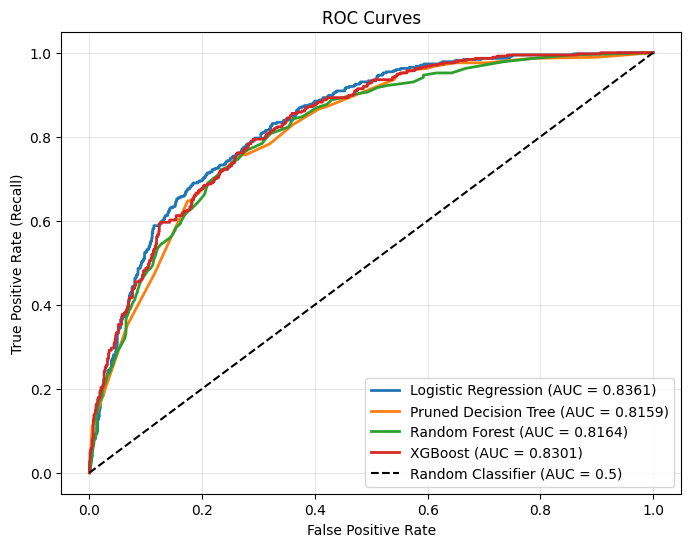


Best model by AUC: Logistic Regression (AUC = 0.8361)

Top features from ensembles (combined RF & XGB top 10):
                       Feature  RF_Importance  XGB_Importance
             Contract_One year       0.000000        0.160577
             Contract_Two year       0.028551        0.155675
   InternetService_Fiber optic       0.037653        0.427907
            InternetService_No       0.000000        0.056550
                MonthlyCharges       0.169814        0.000000
             MultipleLines_Yes       0.000000        0.012693
            OnlineSecurity_Yes       0.026137        0.011458
          PaperlessBilling_Yes       0.026801        0.000000
PaymentMethod_Electronic check       0.036589        0.013501
           StreamingMovies_Yes       0.000000        0.020251
               TechSupport_Yes       0.023269        0.010736
                  TotalCharges       0.193760        0.000000
                   gender_Male       0.029089        0.000000
                    

In [7]:
# Compute all metrics including AUC
def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    return acc, prec, rec, f1, auc_score
# Prepare model outputs
models = {
    'Logistic Regression': (y_pred_logreg, y_pred_prob_logreg),
    'Pruned Decision Tree': (y_pred_pruned_test, pruned_tree.predict_proba(X_test_scaled)[:, 1]),
    'Random Forest': (y_pred_rf, y_pred_prob_rf),
    'XGBoost': (y_pred_xgb, y_pred_prob_xgb)
}
rows = []
for name, (y_pred_i, y_prob_i) in models.items():
    acc, prec, rec, f1, auc_score = compute_metrics(y_test, y_pred_i, y_prob_i)
    rows.append([name, acc, prec, rec, f1, auc_score])
comparison_df = pd.DataFrame(rows, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']).set_index('Model')
print("\nMODEL PERFORMANCE COMPARISON:")
print(comparison_df.round(4))
# Identify model with highest Recall
best_recall_model = comparison_df['Recall'].idxmax()
best_recall_score = comparison_df.loc[best_recall_model, 'Recall']
print(f"\nModel with highest Recall: {best_recall_model} (Recall = {best_recall_score:.4f})")
# Confusion matrix for best recall model
y_pred_best = models[best_recall_model][0]
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title(f'Confusion Matrix - {best_recall_model} (Recall: {best_recall_score:.4f})', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Analysis for {}:".format(best_recall_model))
print("True Negatives: ", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives: ", tp)
print("False Negative Rate: {:.2%}".format(fn / (fn + tp) if (fn + tp) > 0 else 0.0))
print("False Positive Rate: {:.2%}".format(fp / (fp + tn) if (fp + tn) > 0 else 0.0))
# ROC curves for all models
plt.figure(figsize=(8, 6))
for name, (y_pred_i, y_prob_i) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob_i)
    auc_score = roc_auc_score(y_test, y_prob_i)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
# Determine best overall model by AUC
best_auc_model = comparison_df['AUC'].idxmax()
best_auc_score = comparison_df.loc[best_auc_model, 'AUC']
print(f"\nBest model by AUC: {best_auc_model} (AUC = {best_auc_score:.4f})")
# Feature importances
rf_importances = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

xgb_importances = pd.DataFrame({
    'Feature': X.columns,
    'XGB_Importance': xgb_model.feature_importances_
}).sort_values('XGB_Importance', ascending=False)
feature_importance_combined = pd.merge(
    rf_importances.head(10),
    xgb_importances.head(10),
    on='Feature',
    how='outer'
).fillna(0)

print("\nTop features from ensembles (combined RF & XGB top 10):")
print(feature_importance_combined.to_string(index=False))
# Short business recommendations
print("\nBusiness recommendations")
print("- Prioritize retention offers for month-to-month contract customers.")
print("- Focus onboarding for new customers (low tenure).")
print("- Improve services for fiber-optic users and promote TechSupport/OnlineSecurity.")
print("- Review paperless billing experience to reduce churn.")

The model performance comparison indicates that Logistic Regression performs best overall, achieving the highest Recall (0.5722) and AUC (0.8361), suggesting it is most effective at correctly identifying churn cases while maintaining strong discriminatory power. Feature importance analysis from the ensembles highlights key drivers of churn: contract type, tenure, total charges, monthly charges, and fiber-optic internet usage, indicating that customers on shorter contracts or with newer accounts are more prone to churn.